In [1]:
# use anaconda python 3.8 base on local machine
# use miniconda python 3.11.5 on cluster

import numpy as np
import pandas as pd
import seaborn as sns
import os, sys, glob
from matplotlib import pyplot as plt
import scipy.io as sio
import scipy as sp
import nilearn as nil
from nilearn import plotting

from scipy.stats import f_oneway
import statsmodels.api as sm
from tqdm import trange


ModuleNotFoundError: No module named 'seaborn'

In [41]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

# brainspace modules
from brainspace.utils.parcellation import map_to_labels
from brainspace.datasets import load_group_fc, load_parcellation
from brainspace.plotting import plot_hemispheres
from brainspace.datasets import load_conte69

# 0_Global variables

In [42]:
global HOME, DISGROUPS, SUB_LIST, SUB_ID_GROUP, WMH_LAB, WMH_LAB4, ATLAS
HOME = "/public_bme/data/v-baishw/CSVD"
disease_groups = [
    ["Dementia", "a-MCI", "na-MCI", "NCI", "HC"],
    ["Dementia", "MCI", "NCI", "HC"],
    ["a-MCI", "na-MCI", "NCI"],
    ["Dementia", "a-MCI", "na-MCI", "NCI"],
    ["AD", "Dementia", "a&md-MCI", "a-MCI", "na-MCI", "HC", "NCI"],
]
DISGROUPS = disease_groups[3]
ATLAS = "schaefer-400"
SC_LIST = list(set([sub[0:7] for sub in os.listdir(f"{HOME}/data/scs")]))
FC_LIST = list(set([sub[0:7] for sub in os.listdir(f"{HOME}/data/fcs")]))
SUB_LIST = sorted(list(set(SC_LIST) & set(FC_LIST)))
print(
    "SC=", len(SC_LIST),"FC=", len(FC_LIST),"SUB_LIST: list, format is like this: ",
    SUB_LIST[0],
    ", and total length of SUB_LIST =",
    len(SUB_LIST),
)

SC= 387 FC= 462 SUB_LIST: list, format is like this:  sub-011 , and total length of SUB_LIST = 353


In [43]:
# Python
sub_info = pd.read_excel(f"{HOME}/data/ToProfessorShen20210322.xlsx")
diag_col = "diagnosis-merge"
sub_info = sub_info[sub_info[diag_col].isin(DISGROUPS)]

# fiter the sub_info by isenrolled
sub_info.isenrolled = sub_info.pid.isin(SUB_LIST).astype(int)
sub_info = sub_info[sub_info.isenrolled == 1]
SUB_LIST = sub_info[sub_info.pid.isin(SUB_LIST)]["pid"].tolist()


# get the diagnosis dict
SUB_ID_GROUP = sub_info.set_index("pid")[diag_col].to_dict()

WMH_LAB = ["INT", "Mixed", "WMH"]
WMH_LAB4 = ["INT", "UNC", "Mixed", "WMH"]
# get the binary diagnosis
# sub_id_dia_bin = {k: 'PT' if v != 'HC' else v for k, v in SUB_ID_GROUP.items()}
list(SUB_ID_GROUP.values()).count("Dementia")

40

In [44]:
# load schafer 400 7 net label and name
schafer_7net_lab = pd.read_csv(
    f"{HOME}/parc/schaefer400x7CommunityAffiliation.1D", names=["label"]
)["label"].to_list()
schafer_7net_name = pd.read_csv(
    f"{HOME}/parc/schaefer400x7CommunityNames.txt", names=["name"]
)["name"].to_list()
schafer_7net_lab = np.array(schafer_7net_lab)

# brainspace
surf_lh, surf_rh = load_conte69()
labeling = load_parcellation("schaefer", scale=400, join=True)

# 0_Functions

In [45]:
def glob_mat_corr(
    fc, sc, inf_nan_mask=1, cust_mask=np.ones((400, 400)), cust_mask_val=1
):
    # calculate the rsq of fc and matrices correlations for whole matrix
    # fs should be inputed before sc!!!
    # print(cust_mask)
    if inf_nan_mask:
        # mask = sc != 0

        cust_mask = cust_mask == cust_mask_val
        mask = np.logical_and(np.isfinite(sc), cust_mask)
        # np.isfinite can exlcude nan values
        np.fill_diagonal(mask, True)
        sc = sc[mask]
        fc = fc[mask]

    sc = sp.stats.zscore(sc)
    fc = sp.stats.zscore(fc)

    if not np.isnan(sc).any() and len(sc) > 2:
        (r, p) = sp.stats.pearsonr(np.ravel(sc), np.ravel(fc))
        rsq = r**2
    else:
        rsq, p = np.nan, np.nan
    return (rsq, p)


def regional_mat_corr(fc, sc):
    # Calculate the rsq of fc and matrices correlations for each row/node
    # FC should be inputed before SC!!!
    reg_mat_r = []
    reg_mat_p = []
    for n in range(len(fc)):
        fcn = fc[n]
        scn = sc[n]
        mask = np.isfinite(scn)
        fcn = fcn[mask]
        scn = scn[mask]
        if len(fcn) > 2:
            r, p = sp.stats.pearsonr(fcn, scn)
            rsq = r**2
        else:
            rsq, p = np.nan, np.nan

        reg_mat_r.append(rsq)
        reg_mat_p.append(p)
    return reg_mat_r, reg_mat_p


def anova(tbl, group=DISGROUPS, tblval="rsq"):
    # one-way ANOVA
    f_list = [tbl[tbl.Group == DISGROUPS[i]][tblval] for i in range(len(DISGROUPS))]
    f_statistic, p_value = f_oneway(*f_list)
    return f_statistic, p_value


def get_mean_matrix(mat):
    # get the mean matrix for sc, fc and lesion map
    mean_mat = np.zeros((400, 400, len(DISGROUPS)))
    mean_n = np.zeros(len(DISGROUPS))
    for sub in SUB_LIST:
        mat_data =np.load(f"{HOME}/data/{mat}s/" + sub + f"_{mat}-wb_{ATLAS}.npy")
        mean_idx = DISGROUPS.index(SUB_ID_GROUP[sub])
        mean_mat[:, :, mean_idx] += mat_data
        mean_n[mean_idx] += 1
    mean_n = np.where(mean_n != 0, mean_n, 1)
    mean_mat = mean_mat / mean_n[None, None, :]
    return (mean_mat, mean_n)


def get_lesion_matrix(mat):
    # get the mean matrix for sc, fc and lesion map
    mean_mat = np.zeros((400, 400, len(DISGROUPS), 4))
    mean_n = np.zeros(len(DISGROUPS))
    for sub in SUB_LIST:
        mat_data = np.load(f"{HOME}/data/{mat}s/" + sub + f"_{mat}-wb_{ATLAS}.npy")
        mean_idx = DISGROUPS.index(SUB_ID_GROUP[sub])
        mean_n[mean_idx] += 1
        for m in range(4):
            mean_mat[:, :, mean_idx, m] += np.where(mat_data == m - 1, 1, 0)

    mean_n = np.where(mean_n != 0, mean_n, 1)
    for m in range(4):
        mean_mat[:, :, :, m] = mean_mat[:, :, :, m] / mean_n[None, None, :]
    return (mean_mat, mean_n)


def plot_group_matrix(mat, plot_data, plot_n, m=0):
    if mat == "fc":
        vmin, vmax, cmap, ylab = -1, 1, "RdBu_r", "FC"
    elif mat == "sc":
        vmin, vmax, cmap, ylab =-1, 1, "RdBu_r", "SC"
    elif mat == "lm":
        vmin, vmax, cmap, ylab = -1, 1, "RdBu_r", WMH_LAB4[m]
    fig, axes = plt.subplots(1, len(DISGROUPS), figsize=(20, 8))
    for i in range(len(DISGROUPS)):
        plotting.plot_matrix(
            mat=plot_data[:, :, i],
            axes=axes[i],
            colorbar=(i == len(DISGROUPS) - 1),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

    for i in range(len(DISGROUPS)):
        axes[i].set_title(DISGROUPS[i] + " N=" + str(int(plot_n[i])), fontsize=36)
        # axes[i].set_co
    axes[0].set_ylabel(ylab, fontsize=36)
    plt.rcParams["grid.linewidth"] = 0
    plt.grid(False)
    plt.show()

# 0_Must_run_the_codes_above_everytime

# 1_S-F_coulping_in_SCVD
##  1.1_Global_SFC

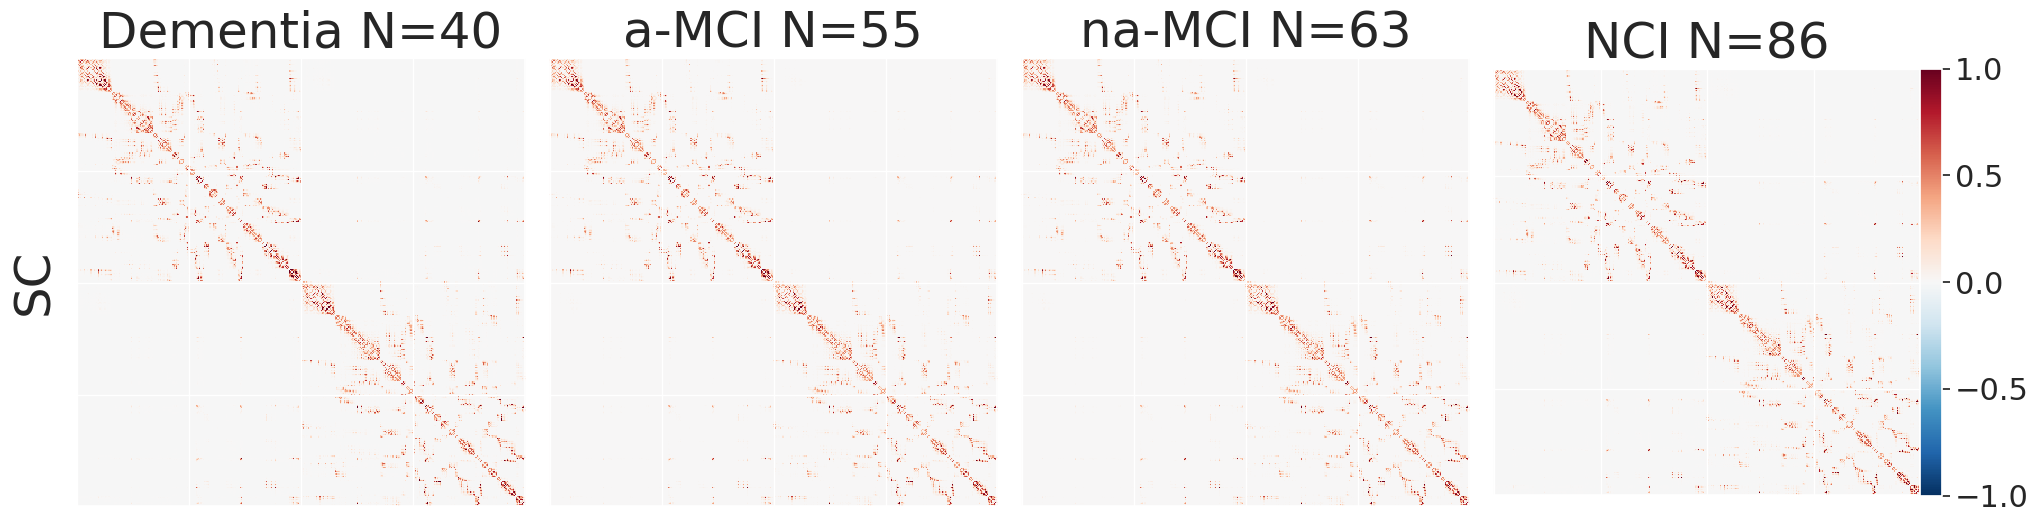

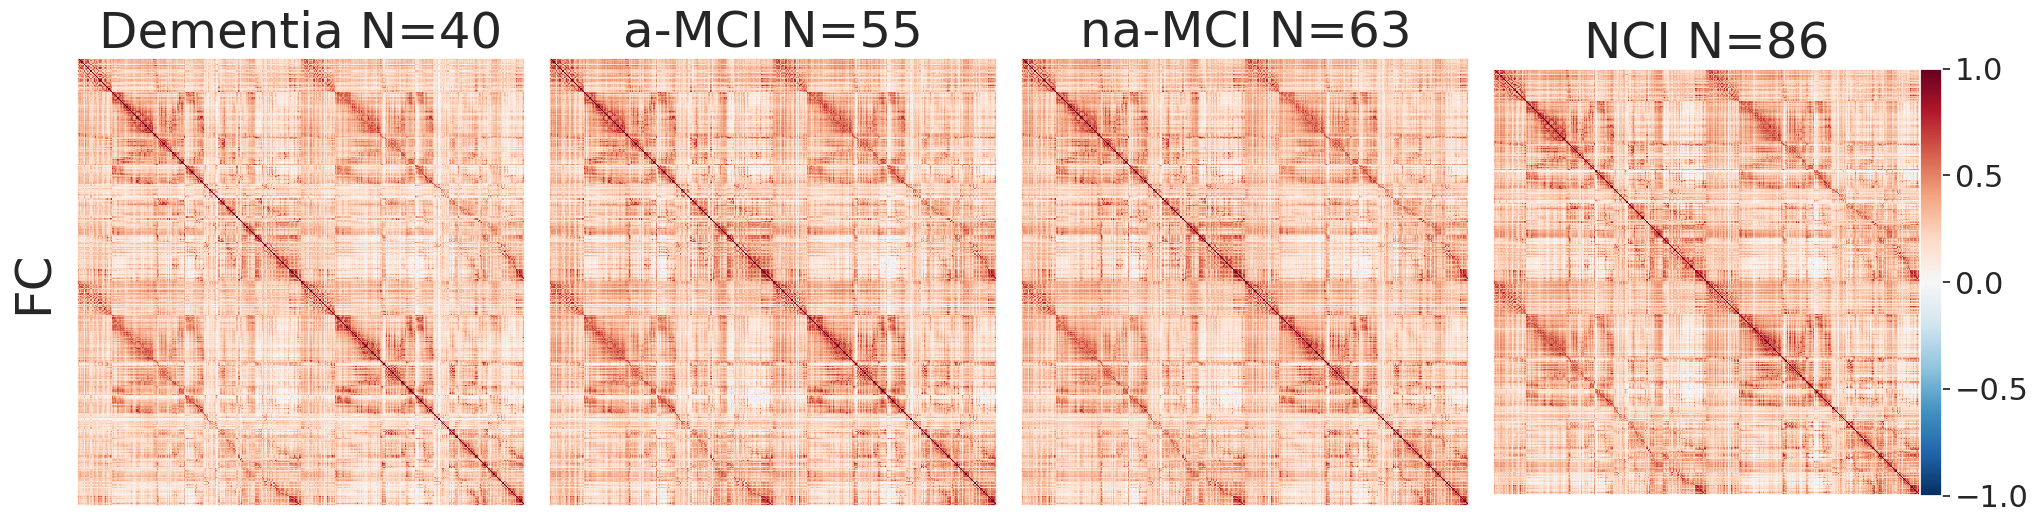

In [46]:
# Mean SC and FC 
plot_group_matrix('sc', *get_mean_matrix('sc'))
plot_group_matrix('fc', *get_mean_matrix('fc'))

## Global SFC

In [47]:
glob_sfc = []
glob_sfc_nsig = 0
sub_list_len = len(SUB_LIST)

for i, sub_id in enumerate(SUB_LIST):
    fc = np.load(f"{HOME}/data/fcs/" + sub_id + f"_fc-wb_{ATLAS}.npy")
    sc = np.load(f"{HOME}/data/scs/" + sub_id + f"_sc-wb_{ATLAS}.npy")
    
    rsq, pval = glob_mat_corr(fc, sc)
    sub_res = {"pid": sub_id, "Group": SUB_ID_GROUP[sub_id], "rsq": rsq, "pval": pval}
    glob_sfc.append(sub_res)
    
    if pval < 0.05:
        glob_sfc_nsig += 1

glob_sfc = pd.DataFrame(glob_sfc)
print(
    "N for subjects with p val < 0.05: %d , and total: %d"
    % (glob_sfc_nsig, sub_list_len)
)


N for subjects with p val < 0.05: 244 , and total: 244


## compare global SFC rsq

In [48]:
display(glob_sfc.groupby('Group').rsq.mean())

Group
Dementia    0.035718
NCI         0.034469
a-MCI       0.032379
na-MCI      0.033436
Name: rsq, dtype: float64

In [49]:
f, p  = anova(glob_sfc)
f, p

(1.0242709334293596, 0.3825192631655785)

/tmp/ipykernel_42032/464604363.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(
/public/home/baishw/apps/miniconda3/lib/python3.11/site-packages/seaborn/categorical.py:3370: UserWarning: 11.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_42032/464604363.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=-90)
/public/home/baishw/apps/miniconda3/lib/python3.11/site-packages/seaborn/categorical.py:3370: UserWarning: 10.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


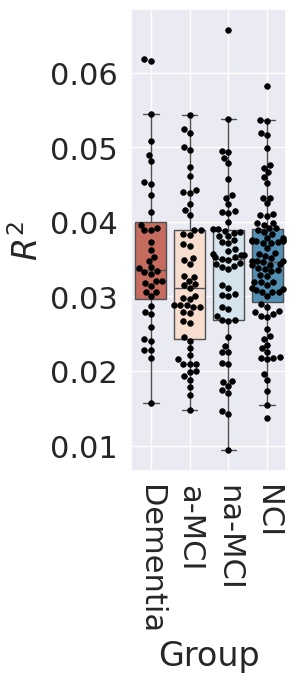

In [50]:
sfc_st = glob_sfc.drop("pval", axis=1).set_index(["pid", "Group"]).stack().reset_index()

sfc_st.columns = ["pid", "Group", "item", "rsq"]

plt.subplots(figsize=(2, 6))
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
sns.set(font_scale=2)
g = sns.boxplot(
    x="Group", y="rsq", order=DISGROUPS, fliersize=0, palette="RdBu", data=sfc_st
)

g = sns.swarmplot(
    x="Group",
    y="rsq",
    size=4,
    color="black",
    linewidth=0.6,
    order=DISGROUPS,
    data=sfc_st,
    dodge=True,
)

g.set_xticklabels(g.get_xticklabels(), rotation=-90)


plt.rcParams.update({"font.size": 16})
g.set_ylabel("$R^2$")
g.set_xlabel("Group")
plt.grid(True, color="white", linewidth=1)
# plt.title('Global SFC')
plt.show()

## correlation coefficient btw cognitive sfc and function

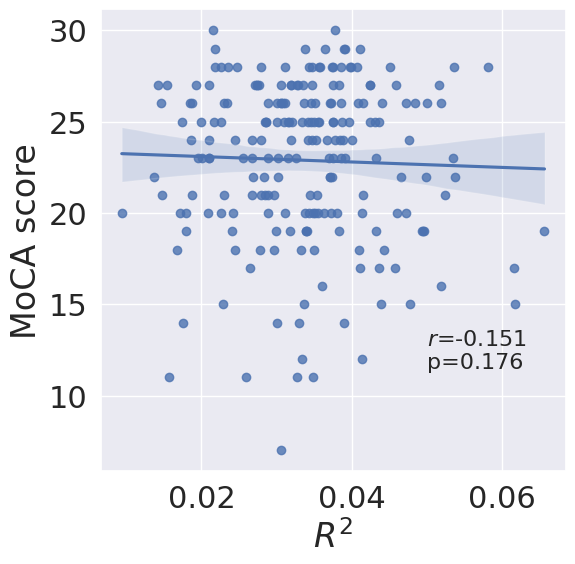

rho= -0.03361107205945401 , pval= 0.6256994726674626


In [51]:
# glob_sfc['mmse'] = glob_sfc['pid'].apply(lambda x: sub_info['门诊MMSE'])

cog_score = 'MoCA-merge'
# cog_score ='门诊MMSE'

glob_sfc_cog = glob_sfc
glob_sfc_cog['cog'] = glob_sfc_cog['pid'].apply(
    lambda x: sub_info[sub_info['pid'] == x][cog_score].values[0])

glob_sfc_cog = glob_sfc_cog.dropna()
c, p = sp.stats.pearsonr(glob_sfc_cog.cog, glob_sfc_cog.rsq)

plt.subplots(figsize=(6, 6))
g = sns.regplot(x=glob_sfc['rsq'], y=glob_sfc['cog'])
g.set_xlabel('$R^2$')
g.set_ylabel('MMSE score')
g.set_ylabel('MoCA score')
# g.legend(format(c, '.3f'))
# plt.title("correlations between sfc and cognitive functions")
# plt.text(0.05, 16,'$\mathit{r}$=-0.074 \np=0.498')
plt.text(0.05, 11.5,'$\mathit{r}$=-0.151 \np=0.176')
plt.show()
print("rho=", str(c), ", pval=", str(p))

# Diffusion 

In [56]:
fg_sub_list = list(set([sub[0:7] for sub in os.listdir(f"{HOME}/data/cm/fg-wei")]))
SUB_LIST = sub_info[sub_info.pid.isin(fg_sub_list)]["pid"].tolist()
SUB_ID_GROUP = sub_info.set_index("pid")[diag_col].to_dict()
fg_sub_list =  sorted(list(set(fg_sub_list) & set(SUB_ID_GROUP)))
glob_fgfc = []
glob_fgfc_nsig = 0
sub_list_len = len(fg_sub_list)
markov_t = np.arange(0.2, 15.2, 0.2)
print(fg_sub_list)
for i, sub_id in enumerate(fg_sub_list):
    fc = np.load(f"{HOME}/data/fcs/" + sub_id + f"_fc-wb_{ATLAS}.npy")
    cms = np.load(f"{HOME}/data/cm/fg-wei/" + sub_id + f"_wb_fg-wei_{ATLAS}.npy")
    for i, t in enumerate(markov_t):
        cm = cms[i]
        # print(np.shape(cm))
        rsq, pval = glob_mat_corr(fc, cm)
        sub_res = {
            "pid": sub_id,
            "Group": SUB_ID_GROUP[sub_id],
            "t": t,
            "rsq": rsq,
            "pval": pval,
        }
        glob_fgfc.append(sub_res)
        if pval<0.05:
            sub_list_len+=1

glob_fgfc = pd.DataFrame(glob_sfc)
print(
    "N for subjects with p val < 0.05: %d , and total: %d"
    % (glob_sfc_nsig, sub_list_len)
)

['sub-011', 'sub-019', 'sub-045', 'sub-049', 'sub-052', 'sub-064', 'sub-070', 'sub-085', 'sub-089', 'sub-091', 'sub-092', 'sub-093', 'sub-094', 'sub-096', 'sub-097', 'sub-100', 'sub-102', 'sub-103', 'sub-106', 'sub-116', 'sub-118', 'sub-125', 'sub-126', 'sub-129', 'sub-136', 'sub-137', 'sub-141', 'sub-150', 'sub-153', 'sub-168', 'sub-173', 'sub-176', 'sub-177', 'sub-183', 'sub-184', 'sub-185', 'sub-186', 'sub-190', 'sub-193', 'sub-199', 'sub-200', 'sub-202', 'sub-213', 'sub-215', 'sub-219', 'sub-223', 'sub-229', 'sub-231', 'sub-232', 'sub-234', 'sub-235', 'sub-236', 'sub-237', 'sub-238', 'sub-241', 'sub-244', 'sub-245', 'sub-246', 'sub-247', 'sub-250', 'sub-251', 'sub-254', 'sub-255', 'sub-256', 'sub-257', 'sub-258', 'sub-262', 'sub-270', 'sub-271', 'sub-274', 'sub-279', 'sub-280', 'sub-285', 'sub-286', 'sub-289', 'sub-291', 'sub-292', 'sub-296', 'sub-298', 'sub-299', 'sub-301', 'sub-309', 'sub-310', 'sub-314', 'sub-315', 'sub-317', 'sub-318', 'sub-322', 'sub-324', 'sub-326', 'sub-327'

KeyboardInterrupt: 

#  C-F_coupling

In [78]:
glob_mfc = pd.DataFrame()
glob_mfc_pvs = pd.DataFrame()
net_mfc = pd.DataFrame()
for i in trange(len(SUB_LIST)):
    sub_id = SUB_LIST[i]
    # funtional matrix
    fc = sio.loadmat(f"{HOME}/data/par400/sub{sub_id[-3:]}")['FC']
    mts = sio.loadmat(f"{HOME}/results/scs-matrix/{sub_id}_sc-mat")
    mts_data = mts['mats']
    mts_thead = [s[0] for s in mts['thead'][0] if isinstance(
        s, np.ndarray)]  # col names for the edge matrices
    for mti in range(len(mts_thead)):
        mt = np.array(mts_data[:, :, mti])
        is_all_nan = np.all(np.isnan(mt))
        if is_all_nan:
            pass
        else:
            (rsq, pv) = glob_mat_corr(fc, mt, 1)
            glob_mfc = glob_mfc.append({'pid': sub_id,
                                        'Group': SUB_ID_GROUP[sub_id],
                                        'Mat': mts_thead[mti],
                                        'rsq': rsq,
                                        'pval': pv},
                                       ignore_index=True)
            #Network
            for i, netwk in enumerate(schafer_7net_name):
                mask_netwk = schafer_7net_lab == i+1
                mt_netwk = mt[mask_netwk]
                fc_netwk = fc[mask_netwk]
                (rsq, pv) = glob_mat_corr(fc_netwk, mt_netwk, 1)
                net_mfc = net_mfc.append({'pid': sub_id,
                                                'Group': SUB_ID_GROUP[sub_id],
                                                'Net': netwk,
                                                'Mat': mts_thead[mti],
                                                'rsq': rsq,
                                                'pval': pv},
                                               ignore_index=True)

  0%|          | 0/244 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/public_bme/data/v-baishw/CSVD/data/par400/sub011.mat'

## ANOVA for Global 

In [14]:
#  get the percentage of subjects with significantly correlated mts
sig_corr_count = glob_mfc[glob_mfc['pval'] < 0.05].groupby('Mat')['pval'].count().to_dict()
sig_corr_percent = {key: value / len(SUB_LIST) for key, value in sig_corr_count.items()}
print(sig_corr_percent)

{'Cosbin': 0.8275862068965517, 'Coswei': 0.8620689655172413, 'FGbin-1': 0.5632183908045977, 'FGbin-10': 0.5517241379310345, 'FGbin-2.5': 0.5632183908045977, 'FGbin-5': 0.5517241379310345, 'FGwei-1': 0.6896551724137931, 'FGwei-10': 0.6436781609195402, 'FGwei-2.5': 0.5977011494252874, 'FGwei-5': 0.6091954022988506, 'Gbin': 0.367816091954023, 'Gwei': 0.6896551724137931, 'MIbin': 0.8275862068965517, 'MIwei': 0.8735632183908046, 'NavplMS': 0.8620689655172413, 'PLwei-0.25': 0.8505747126436781, 'PLwei-0.5': 0.9425287356321839, 'PLwei-1': 0.9425287356321839, 'PLwei-2': 0.9310344827586207, 'PLwei-4': 0.8620689655172413, 'PTbin': 0.8275862068965517, 'PTwei-0.25': 0.7471264367816092, 'PTwei-0.5': 0.7931034482758621, 'PTwei-1': 0.9080459770114943, 'PTwei-2': 0.8620689655172413, 'PTwei-4': 0.8735632183908046, 'SIbin': 0.632183908045977, 'SIwei-0.25': 0.8390804597701149, 'SIwei-0.5': 0.8390804597701149, 'SIwei-1': 0.8390804597701149, 'SIwei-2': 0.8390804597701149, 'SIwei-4': 0.6666666666666666, 'dis

In [18]:
pval_uncorr = []
mat_anova_sig = []
for n in trange(len(mts_thead)):
    f_statistic, p_value = anova(glob_mfc[glob_mfc.Mat==mts_thead[n]])
    if p_value<0.05:
        mat_anova_sig.append(mts_thead[n])
        print(mts_thead[n], p_value)


100%|██████████| 37/37 [00:00<00:00, 390.52it/s]

Gwei 0.03048150206412829
MIwei 0.03312468064585735
FGwei-1 0.043849982446235905


In [16]:
glob_mfc[glob_mfc.Mat=='SIwei-0.25'].groupby('Group')['rsq'].mean()

Group
NCI       0.004779
a-MCI     0.005130
na-MCI    0.003654
Name: rsq, dtype: float64

### Fig. 1 variance in whole-brain FC weights explained by factors

In [12]:

# sfc_st['Group'][sfc_st['Group']=='Dementia']='MCI'
# Groupplay(sfc_st)
glob_mfc_select = glob_mfc[glob_mfc.Mat.isin(
    ['distance',
     'PLbin',
    #  'PLwei-0.25',
     'PLwei-0.5',
     'PLwei-1',
    #  'PLwei-2',
    #  'PLwei-4',
     'Gbin',
     'Gwei',
     'Cosbin',
     'Coswei',
     'SIbin',
     'SIwei-0.25',
     'SIwei-0.5',
    #  'SIwei-1',
    #  'SIwei-2',
    #  'SIwei-4',
     'PTbin',
     'PTwei-0.25',
     'PTwei-0.5',
     'PTwei-1',
     'PTwei-2',
    #  'PTwei-4',
     'MIbin',
     'MIwei',
     'Navnumhops',
     'NavplMS',
     'mfptwei',
     'mfptbin',
     'FGbin-1',
     'FGbin-2.5',
     'FGbin-5',
    #  'FGbin-10',
     'FGwei-1',
     'FGwei-2.5',
     'FGwei-5',
    #  'FGwei-10'
     ])
]
glob_mfc_select = glob_mfc[glob_mfc.Mat.isin(mat_anova_sig)]

plt.subplots(figsize=(3, 4))
g = sns.boxplot(x="Mat", y="rsq",
                hue="Group",
                hue_order=DISGROUPS,
                fliersize=0,
                palette='RdBu',

                data=glob_mfc_select)
g = sns.swarmplot(x="Mat", y="rsq",
                  hue="Group", size=3,
                  hue_order=DISGROUPS,
                  color='black', linewidth=0.6,
                  legend='',
                  data=glob_mfc_select, dodge=True)
g.set_xticklabels(g.get_xticklabels(), rotation=-90, fontsize = 20)
# g.set_gid()
g.set_ylabel("$R^2$", fontsize = 20)
# g.set_ylim(0, 0.15)
g.set_xlabel("Communication measures", fontsize = 20)
colors = ['lightgray', 'white']
plt.grid(True, color='gray', linewidth=0.05)

# plt.plot([0.6, 1.4], [0.13, 0.13], linestyle='-', color='black')
# plt.plot([1.6, 2.4], [0.13, 0.13], linestyle='-', color='black')

# plt.legend("")
plt.show()

NameError: name 'mat_anova_sig' is not defined

## ANOVA for regional 

In [19]:
pval_uncorr = []
mat_anova_sig = []

for n in trange(len(mts_thead)):
    for netwk in schafer_7net_name:

        f_statistic, p_value = anova(net_mfc[(net_mfc.Mat == mts_thead[n]) & (
            net_mfc.Net == netwk)])
        if p_value < 0.01 and mts_thead[n] in glob_mfc_select.Mat.to_list():
            mat_anova_sig.append((netwk, mts_thead[n],  f_statistic, p_value))

  0%|          | 0/37 [00:00<?, ?it/s]d:\ProgramFiles\Anaconda3\lib\site-packages\scipy\stats\stats.py:3680: F_onewayBadInputSizesWarning: at least one input has length 0
  warnings.warn(F_onewayBadInputSizesWarning('at least one input '
100%|██████████| 37/37 [00:01<00:00, 31.54it/s]


In [20]:

mat_anova_sig = sorted(mat_anova_sig)
len(mat_anova_sig)
mat_anova_sig



[('default', 'MIwei', 7.038219267028677, 0.0014928396681908728),
 ('default', 'PLwei-0.5', 5.905855580065186, 0.003982437408721828),
 ('frontoparietalControl',
  'FGbin-5',
  5.660035043629143,
  0.0054527586144806255),
 ('frontoparietalControl', 'MIbin', 6.023439413447469, 0.0035928016712716113),
 ('frontoparietalControl', 'MIwei', 6.987420243060576, 0.0015592590794902734),
 ('frontoparietalControl',
  'PLwei-0.5',
  6.136646567169452,
  0.0032545073429076335),
 ('frontoparietalControl',
  'PLwei-1',
  6.648508285835233,
  0.0020871325011108653),
 ('limbic', 'MIwei', 6.179829806211777, 0.0031342180856363836),
 ('salienceVentralAttention',
  'MIbin',
  6.055489107530553,
  0.003493527120910978),
 ('salienceVentralAttention',
  'MIwei',
  5.906256984270942,
  0.0039810361661230895),
 ('somatomotor', 'MIbin', 5.225781940959598, 0.007260149811244879),
 ('somatomotor', 'MIwei', 7.006002755939757, 0.0015346185092771998),
 ('visual', 'MIwei', 5.200230505558077, 0.007427064161951359)]

In [15]:
net_mfc = net_mfc[~net_mfc.Mat.isin(['PLbin','Navnumhops'])]

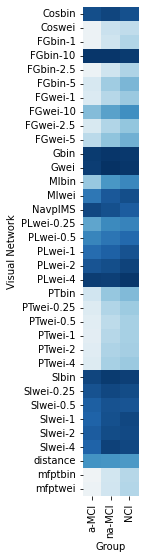

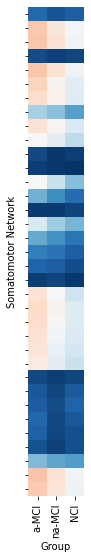

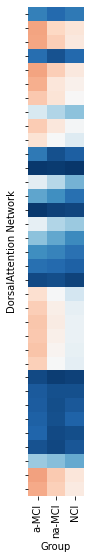

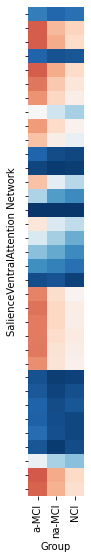

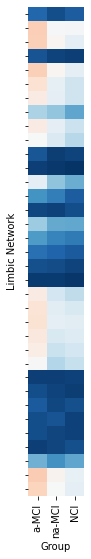

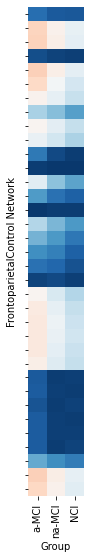

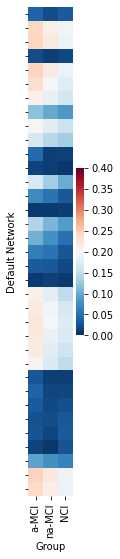

In [18]:
for i,net in enumerate(schafer_7net_name):
    plt.subplots(figsize=(1,9))
    net_mfc_heat = net_mfc[['Group', 'Mat', 'rsq']
                           ][net_mfc.Net == net].groupby(['Group', 'Mat']).mean().reset_index().pivot(
        index="Mat", columns="Group", values="rsq")
                           
    net_mfc_heat = net_mfc_heat.reindex(columns=DISGROUPS)
    g = sns.heatmap(data=net_mfc_heat, cmap='RdBu_r', vmax=0.4, vmin=0.0,cbar=i>5)
    # g.set_title(net)
    g.set_ylabel(net[0].upper()+net[1:]+' Network')
    # g.set_ylabel)_
    if i!=0:
        
        g.set_yticklabels('')
    plt.show()

d:\ProgramFiles\Anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 15.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
d:\ProgramFiles\Anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 17.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


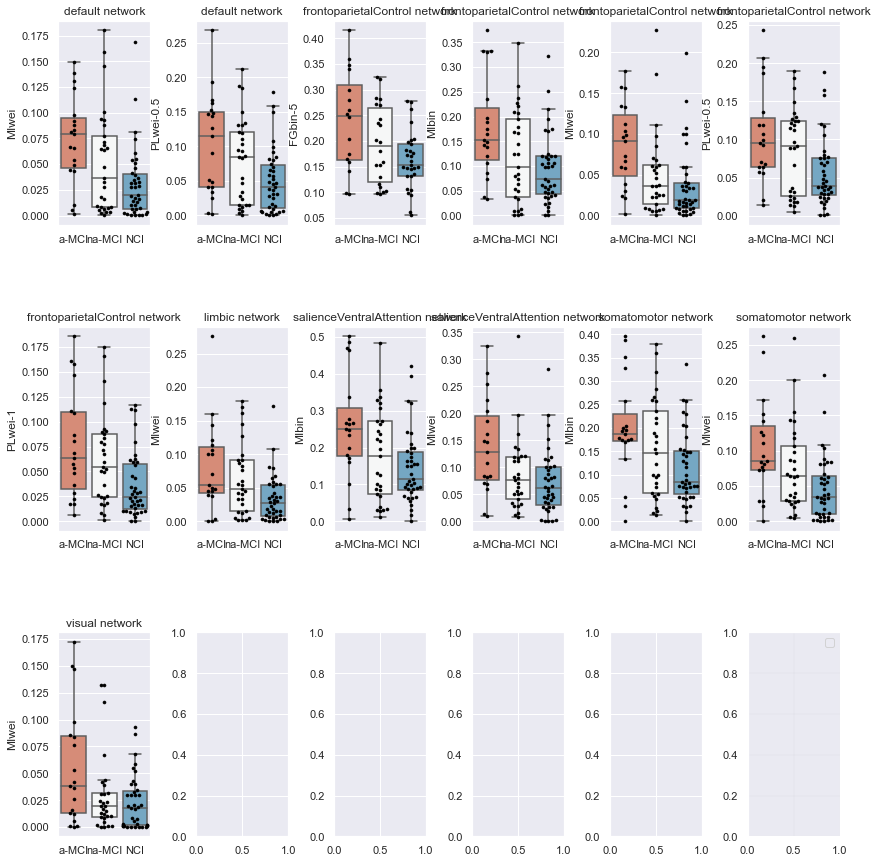

In [21]:
# net_mfc_nodementia = net_mfc[net_mfc.Group.isin([DISGROUPS])]
sns.set(font_scale=1)
fig, axes = plt.subplots(3, 6, figsize=(14, 15))
for i, mat_net in enumerate(mat_anova_sig):
    
    plot_data = net_mfc[(net_mfc.Mat == mat_net[1]) &
                        (net_mfc.Net == mat_net[0])]
    g = sns.boxplot(x="Group",
                    y="rsq",
                    palette='RdBu',
                    data=plot_data,
                    order=DISGROUPS,
                    fliersize=0,
                    ax=axes[i // 6, i % 6]
                    )
    g = sns.swarmplot(x="Group", y="rsq",
                        size=3,
                        color='black',
                        linewidth=0.6,
                        data=plot_data,
                        order=DISGROUPS,
                        dodge=True,
                        ax=axes[i // 6, i % 6])
    g.set_xticklabels(g.get_xticklabels())
    g.set_ylabel("")
    g.set_xlabel("")
    g.set_title(mat_net[0] + ' network')
# # g.set_gid()
    g.set_ylabel(mat_net[1])
# # g.set_ylim(0, 0.15)
# g.set_xlabel("Communication measures")
colors = ['lightgray', 'white']
plt.grid(True, color='gray', linewidth=0.05)

plt.subplots_adjust(hspace=0.5, wspace=0.5)
# plt.plot([0.6, 1.4], [0.13, 0.13], linestyle='-', color='black')
# plt.plot([1.6, 2.4], [0.13, 0.13], linestyle='-', color='black')

plt.legend("")
plt.show()
fig.savefig('D:/Shanghaitec/PROJECT/CSVD/results/fig/4.pdf')

In [ ]:

fig.savefig('D:/Shanghaitec/PROJECT/CSVD/results/fig/3.pdf')

In [ ]:
net_mfc[(net_mfc.Mat == 'PTwei-0.25') & (
    net_mfc.Net == 'default')].groupby('Group')['rsq'].mean()

# Regional correlation coefficient

In [ ]:
region_mfc = pd.DataFrame()
region_mfc_pvs = pd.DataFrame()
for i in trange(len(SUB_LIST)):
    sub_id = SUB_LIST[i]
    # funtional matrix
    fc = sio.loadmat(f"{HOME}/data/par400/sub{sub_id[-3:]}")['FC']
    mts = sio.loadmat(f"{HOME}/results/scs-matrix/{sub_id}_sc-mat")
    mts_data = mts['mats']
    mts_thead = [s[0] for s in mts['thead'][0] if isinstance(
        s, np.ndarray)]  # col names for the edge matrices
    # for mti in range(len(mts_thead)):
    for mti in [8]:
        mt = np.array(mts_data[:, :, mti])
        is_all_nan = np.all(np.isnan(mt))
        if is_all_nan:
            pass
        else:
            (rsq_list, pv_list) = regional_mat_corr(fc, mt)
            for i in range(len(rsq_list)):
                region_mfc = region_mfc.append({'pid': sub_id,
                                                'Group': SUB_ID_GROUP[sub_id],
                                                'Mat': mts_thead[mti],
                                                'ROI': i,
                                                'rsq': rsq_list[i]},
                                               ignore_index=True)
                # region_mfc_pvs = region_mfc_pvs.append({'pid': sub_id,
                #                                         'Group': SUB_ID_GROUP[sub_id],
                #                                         'Mat': mts_thead[mti],
                #                                         'ROI': i,
                #                                         'pval': rsq}, ignore_index=True)

In [ ]:
region_mfc.ROI = region_mfc.ROI.astype('int')

region_mfc_mean = region_mfc.groupby(['ROI', 'Group'])['rsq'].mean()
region_mfc_mean = region_mfc_mean.to_frame().reset_index()
region_mfc_mean.head(5)

## ANOVA

In [ ]:
pval_uncorr = []
rois_anova_sig = []
for n in trange(400):
    region_n_mfc = region_mfc[region_mfc.ROI == n]
    f_statistic, p_value = f_oneway(region_n_mfc[region_n_mfc.Group == 'Dementia']['rsq'],
                                    region_n_mfc[region_n_mfc.Group ==
                                                 'NCI']['rsq'],
                                    region_n_mfc[region_n_mfc.Group ==
                                                 'a-MCI']['rsq'],
                                    region_n_mfc[region_n_mfc.Group == 'na-MCI']['rsq'])
    # 进行事后检验
    multi_comp = pairwise_tukeyhsd(
        endog=region_mfc['rsq'], groups=region_mfc['Group'], alpha=0.05)

    # 将结果存储到DataFrame中
    posthoc = pd.DataFrame(
        data=multi_comp._results_table.data[1:], columns=multi_comp._results_table.data[0])

    pval_uncorr.append(p_value)
    # print("One-way ANOVA p-value:", p_value)
    # print("================================================")
    # print("Post-hoc test results:")
    # print(posthoc)
reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(
    pval_uncorr, method='fdr_bh')
pval_idx_corrected = np.where(pvals_corrected < 0.05)


## Save significant regions

In [ ]:
region_sigs = np.zeros(400)
region_sigs[pval_idx_corrected]=0.8

grad = map_to_labels(region_sigs, labeling, mask=labeling != 0,fill=np.nan)

g=plot_hemispheres(surf_lh, surf_rh,
                        array_name=grad, 
                        size=(900, 200),
                        cmap='RdBu_r',
                        color_bar=True, 
                        screenshot = True, 
                        color_range = (-1,1),
                        filename =f"{HOME}/results/fig/"+mts_thead[8]+"_Pval.png"
                        )
    

In [ ]:
for group in DISGROUPS:
    region_mfc_mean_g= region_mfc_mean[region_mfc_mean.Group==group]
    # display(region_mfc_mean_g)
    grad = map_to_labels(region_mfc_mean_g.rsq, labeling, mask=labeling != 0,fill=np.nan)
    
    g=plot_hemispheres(surf_lh, surf_rh,
                            array_name=grad, 
                            size=(900, 200),
                            cmap='RdBu_r',
                            color_bar=True, 
                            screenshot = True, 
                            color_range = (-1,1),
                            filename =f"{HOME}/results/fig/"+mts_thead[8]+group+".png"
                            )
    

In [ ]:

plt.subplots(figsize=(18, 6))
# sfc_st = sfc_st[sfc_st.Group.isin( ['PT','HC'])]


g = sns.heatmap(
    data= region_mfc.rsq,
)
g.set_xticklabels(g.get_xticklabels(), rotation=-90)
# g.set_gid()
g.set_ylabel("$R^2$")
g.set_xlabel("Structual netwok factors")
colors = ['lightgray', 'white']
plt.grid(True, color='gray', linewidth=0.05)

plt.show()

# 2_WMH_impact
WARNING: the SUB_LIST is reset from here

## 2.1_draw_lesion_maps


In [27]:
# update SUB_LIST
sub_list = os.listdir(f"{HOME}/data/wmh_int")
SUB_LIST = [sub[0:7] for sub in sub_list]
SUB_LIST = [item for item in SUB_LIST if item in SUB_ID_GROUP.keys()]


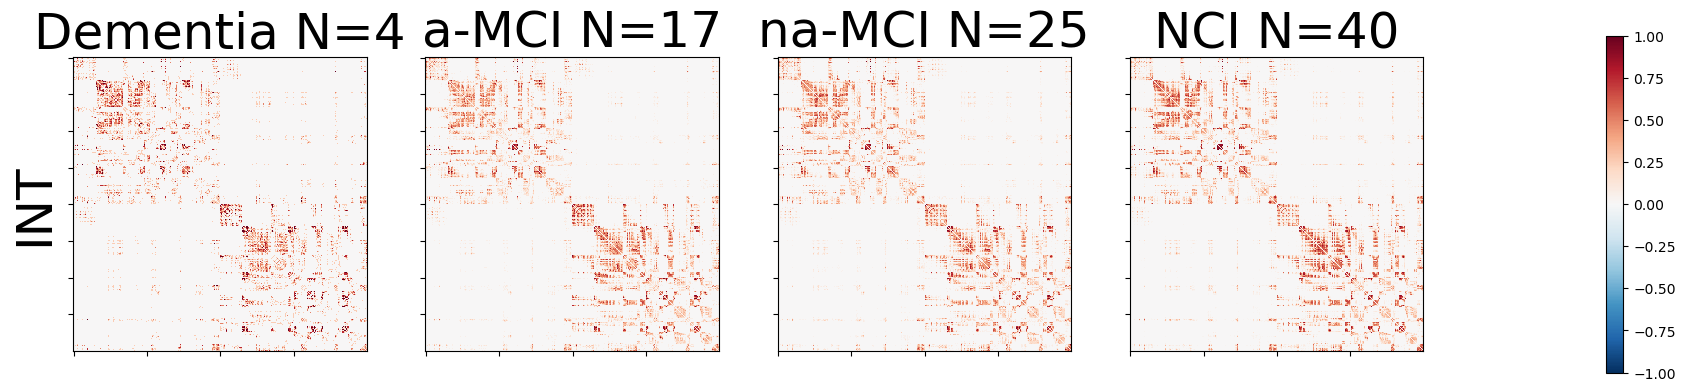

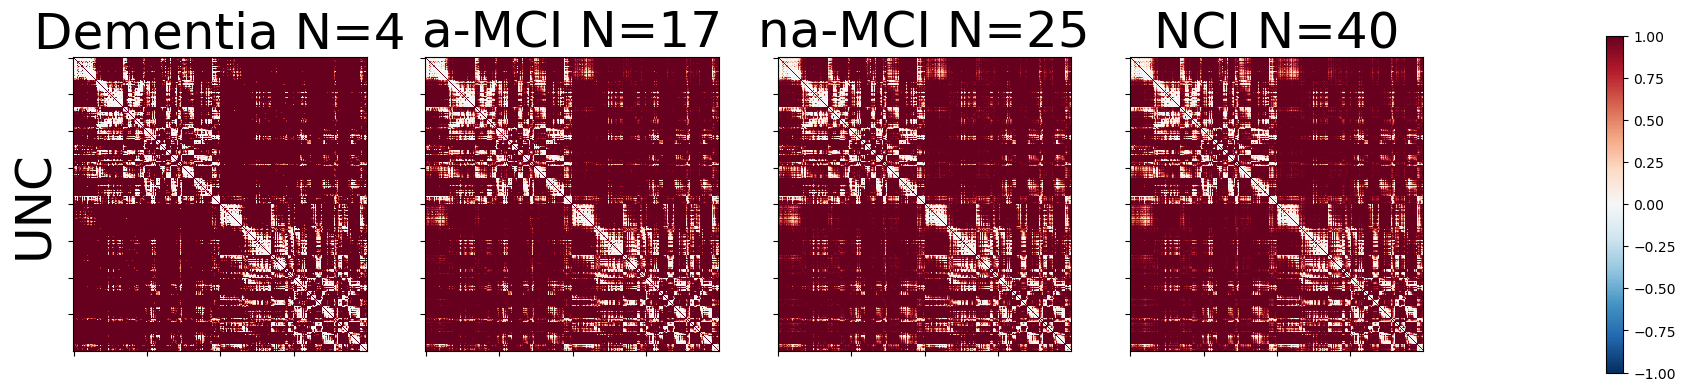

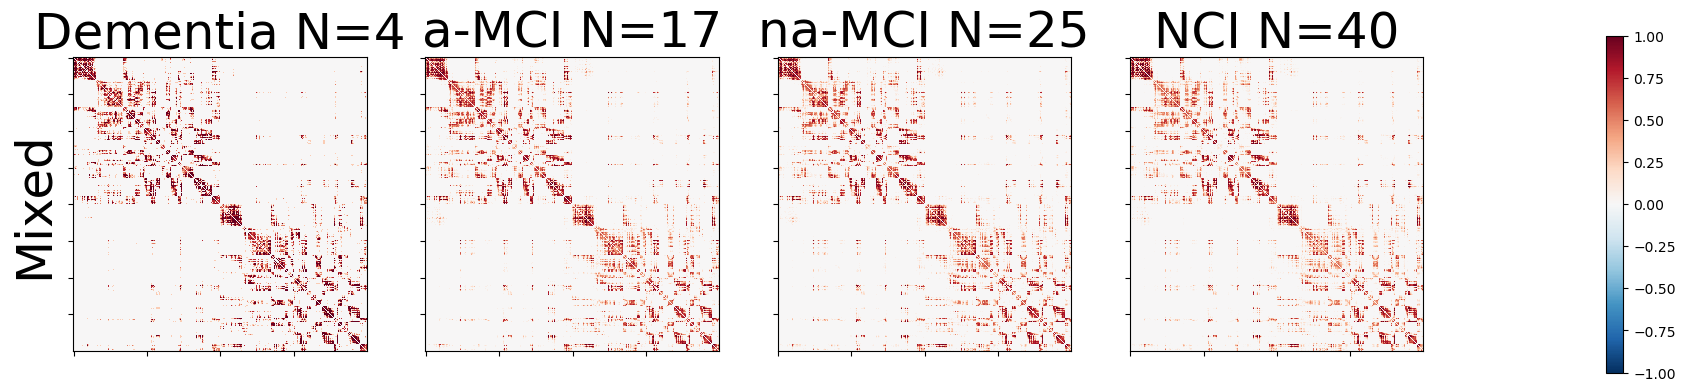

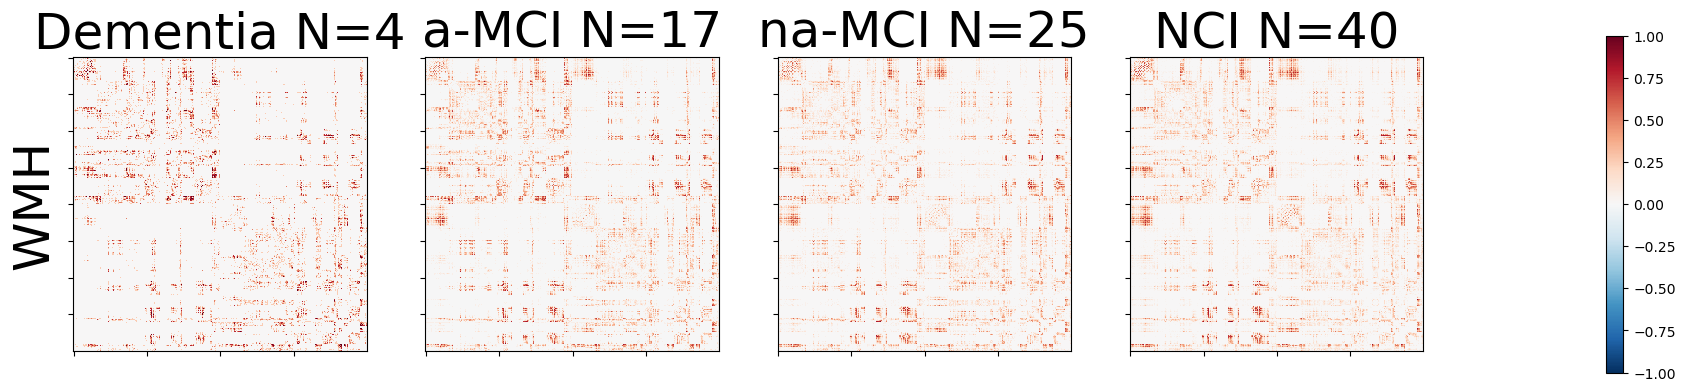

FileNotFoundError: [Errno 2] No such file or directory: 'D:/Shanghaitec/PROJECT/CSVD/data/scs/sub-025_sc-wb_schaefer-400.mat'

In [31]:
glob_mean_mats, glob_mean_n = get_lesion_matrix('lesion')
# glob_mean_mats = glob_mean_mats>0
for m in range(4):
    plot_group_matrix('lesion', glob_mean_mats[:,:,:,m], glob_mean_n, m)
plot_group_matrix('sc', *get_mean_matrix('sc'))

In [225]:
glob_cfc = pd.DataFrame()
glob_cfc_nsig = 0
for i in trange(len(SUB_LIST)):
    sub_id = SUB_LIST[i]

    # load data
    # funtional matrix
    fc = sio.loadmat(f"{HOME}/data/par400/sub{sub_id[-3:]}")['FC']
    # structural matrix
    sc = sio.loadmat(f"{HOME}/data/scs/{sub_id}_sc-wb_schaefer-400.mat")['sc']
    # WMH map
    wmh_lab = sio.loadmat(
        f"{HOME}/data/wmh_int/{sub_id}_sc-wmh_min_int_schaefer-400.mat")['dif']
    wmh_lab = np.array(wmh_lab).astype('int')
    for i, lab in enumerate(WMH_LAB4):
        (rsq, pval) = glob_mat_corr(fc, sc, 1, wmh_lab, i-1 )
        sub_res = {'pid': sub_id, 'Group': SUB_ID_GROUP[sub_id],'Lab': lab, 'rsq': rsq, 'pval': pval}
        glob_cfc = glob_cfc.append(sub_res, ignore_index=True)
        if pval < 0.05:
            glob_cfc_nsig += 1
glob_cfc = glob_cfc[glob_cfc.Lab!='UNC']
print("N for subjects with p val < 0.05: %d , and total: %d" %
      (glob_sfc_nsig, len(SUB_LIST)))

100%|██████████| 87/87 [00:03<00:00, 28.34it/s]

N for subjects with p val < 0.05: 90 , and total: 87


In [226]:
glob_cfc.groupby(['Group', 'Lab']).rsq.mean()

Group   Lab  
NCI     INT      0.025218
        Mixed    0.046931
        WMH      0.003907
a-MCI   INT      0.016898
        Mixed    0.049254
        WMH      0.003350
na-MCI  INT      0.022274
        Mixed    0.046816
        WMH      0.001502
Name: rsq, dtype: float64

In [227]:
for i, lab in enumerate(WMH_LAB):
    f, p = anova(glob_cfc[glob_cfc.Lab == lab])
    multi_comp = pairwise_tukeyhsd(
        endog=glob_cfc[glob_cfc.Lab == lab]['rsq'],
        groups=glob_cfc[glob_cfc.Lab == lab]['Group'],
        alpha=0.05)
    tukeyposthoc = pd.DataFrame(
        data=multi_comp._results_table.data[1:], columns=multi_comp._results_table.data[0])
    display(tukeyposthoc)
    print(lab, f, p)
glob_cfc_nsig
# glob_cfc = glob_cfc.drop('pval', axis=1)


,group1,group2,meandiff,p-adj,lower,upper,reject
0,NCI,a-MCI,-0.0083,0.2163,-0.0201,0.0034,False
1,NCI,na-MCI,-0.0029,0.7550,-0.0133,0.0074,False
2,a-MCI,na-MCI,0.0054,0.5547,-0.0070,0.0178,False


INT 1.4248099636260994 0.2463072987433207


,group1,group2,meandiff,p-adj,lower,upper,reject
0,NCI,a-MCI,0.0023,0.8519,-0.0085,0.0132,False
1,NCI,na-MCI,-0.0001,0.9000,-0.0096,0.0094,False
2,a-MCI,na-MCI,-0.0024,0.8534,-0.0139,0.0090,False


Mixed 0.1585745370653694 0.8536142094177005


,group1,group2,meandiff,p-adj,lower,upper,reject
0,NCI,a-MCI,-0.0006,0.7647,-0.0026,0.0014,False
1,NCI,na-MCI,-0.0024,0.0044,-0.0042,-0.0007,True
2,a-MCI,na-MCI,-0.0018,0.0983,-0.0040,0.0003,False


WMH 5.5349845039747185 0.005519620469965344


233

In [228]:
for i, dis in enumerate(DISGROUPS):
    f, p = anova(glob_cfc[glob_cfc.Group == dis])
    multi_comp = pairwise_tukeyhsd(
        endog=glob_cfc[glob_cfc.Group == dis]['rsq'],
        groups=glob_cfc[glob_cfc.Group == dis]['Lab'],
        alpha=0.05)
    tukeyposthoc = pd.DataFrame(
        data=multi_comp._results_table.data[1:], columns=multi_comp._results_table.data[0])
    display(tukeyposthoc)
    print(lab, f, p)
glob_cfc_nsig

d:\ProgramFiles\Anaconda3\lib\site-packages\scipy\stats\stats.py:3680: F_onewayBadInputSizesWarning: at least one input has length 0
  warnings.warn(F_onewayBadInputSizesWarning('at least one input '


,group1,group2,meandiff,p-adj,lower,upper,reject
0,INT,Mixed,0.0324,0.0010,0.0218,0.0429,True
1,INT,WMH,-0.0135,0.0085,-0.0241,-0.0030,True
2,Mixed,WMH,-0.0459,0.0010,-0.0564,-0.0354,True


WMH nan nan


d:\ProgramFiles\Anaconda3\lib\site-packages\scipy\stats\stats.py:3680: F_onewayBadInputSizesWarning: at least one input has length 0
  warnings.warn(F_onewayBadInputSizesWarning('at least one input '


,group1,group2,meandiff,p-adj,lower,upper,reject
0,INT,Mixed,0.0245,0.001,0.0156,0.0335,True
1,INT,WMH,-0.0208,0.001,-0.0297,-0.0118,True
2,Mixed,WMH,-0.0453,0.001,-0.0543,-0.0364,True


WMH nan nan


d:\ProgramFiles\Anaconda3\lib\site-packages\scipy\stats\stats.py:3680: F_onewayBadInputSizesWarning: at least one input has length 0
  warnings.warn(F_onewayBadInputSizesWarning('at least one input '


,group1,group2,meandiff,p-adj,lower,upper,reject
0,INT,Mixed,0.0217,0.001,0.0142,0.0292,True
1,INT,WMH,-0.0213,0.001,-0.0288,-0.0138,True
2,Mixed,WMH,-0.0430,0.001,-0.0505,-0.0355,True


WMH nan nan


233

d:\ProgramFiles\Anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


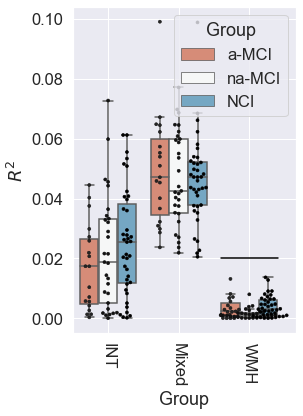

In [235]:

sfc_st = glob_cfc.drop('pval', axis=1).set_index(
    ['pid', 'Group', 'Lab']).stack().reset_index()
sfc_st.columns = ['pid', 'Group', 'Lab', 'item', 'rsq']


plt.subplots(figsize=(4, 6))
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
sns.set(font_scale=1.5)
g = sns.boxplot(x="Lab", y="rsq",
                hue_order=DISGROUPS,
                hue='Group',
                fliersize=0,
                palette='RdBu',
                data=sfc_st)
g = sns.swarmplot(x="Lab", y="rsq", size=3,
                  color='black', linewidth=0.6,
                  hue='Group',
                  hue_order=DISGROUPS,
                  legend='',
                  data=sfc_st, dodge=True)
g.set_xticklabels(g.get_xticklabels(), rotation=-90)

plt.rcParams.update({'font.size': 16})
g.set_ylabel("$R^2$")
g.set_xlabel("Group")
plt.grid(True, color='white', linewidth=1)
# plt.title('Global SFC')
# plt.legend('')
plt.plot([1.6, 2.4], [0.02, 0.02], linestyle='-', color='black')
plt.show()

## 2.3_CFC_GLOBAL_AND_NETWORK

In [11]:
glob_mfc = pd.DataFrame()
glob_mfc_pvs = pd.DataFrame()
net_mfc = pd.DataFrame()

for i in trange(len(SUB_LIST)):
    sub_id = SUB_LIST[i]
    wmh_lab = sio.loadmat(
        f"{HOME}/data/wmh_int/{sub_id}_sc-wmh_min_int_schaefer-400.mat")['dif']
    # funtional matrix
    fc = sio.loadmat(f"{HOME}/data/par400/sub{sub_id[-3:]}")['FC']
    mts = sio.loadmat(f"{HOME}/results/scs-matrix/{sub_id}_sc-mat")
    mts_data = mts['mats']
    mts_thead = [s[0] for s in mts['thead'][0] if isinstance(
        s, np.ndarray)]  # col names for the edge matrices
    for mti in range(len(mts_thead)):
        mt = np.array(mts_data[:, :, mti])
        is_all_nan = np.all(np.isnan(mt))
        if is_all_nan:
            pass
        else:
            (rsq, pv) = glob_mat_corr(fc, mt, 1, wmh_lab, 2)
            glob_mfc = glob_mfc.append({'pid': sub_id,
                                        'Group': SUB_ID_GROUP[sub_id],
                                        'Mat': mts_thead[mti],
                                        'rsq': rsq,
                                        'pval': pv},
                                       ignore_index=True)
            # Network
            for i, netwk in enumerate(schafer_7net_name):
                mask_netwk = schafer_7net_lab == i+1
                mask =  np.logical_and(mask_netwk , wmh_lab == 0)
                (rsq, pv) = glob_mat_corr(fc, mt, 1, mask, True)
                net_mfc = net_mfc.append({'pid': sub_id,
                                          'Group': SUB_ID_GROUP[sub_id],
                                          'Net': netwk,
                                          'Mat': mts_thead[mti],
                                          'rsq': rsq,
                                          'pval': pv},
                                         ignore_index=True)

  3%|▎         | 3/87 [00:04<02:04,  1.49s/it]d:\ProgramFiles\Anaconda3\lib\site-packages\numpy\core\_methods.py:246: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
d:\ProgramFiles\Anaconda3\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
 13%|█▎        | 11/87 [00:20<02:37,  2.07s/it]d:\ProgramFiles\Anaconda3\lib\site-packages\numpy\core\_methods.py:235: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
100%|██████████| 87/87 [02:38<00:00,  1.82s/it]


# go back
[back to the section 1](#C-F_coupling)

In [ ]:
sfc_st = sfc.set_index(['ptid', 'dis']).stack().reset_index()
sfc_st.columns = ['Pid','Group','factor','r2']

# sfc_st = sfc_st.drop(sfc_st[sfc_st.Pid=='sc_sub-003'].index)
sfc_st = sfc_st.drop(sfc_st[sfc_st.Pid=='sc_sub-169'].index)
sfc_st = sfc_st[sfc_st.factor.isin(['PLwei-0.25','SIwei-0.5','PTwei-2','mfptwei','FGwei-2.5'])]
# sfc_st['Group'][sfc_st['Group']=='Dementia']='MCI'
# Groupplay(sfc_st)

plt.subplots(figsize=(4, 6))
sfc_st = sfc_st[sfc_st.Group.isin( ['PT','HC'])]
g = sns.boxplot(x="factor", y="r2", hue="Group",hue_order=['PT','HC'] ,fliersize=0,
                palette='RdBu',
                data=sfc_st)
g = sns.swarmplot(x="factor", y="r2", hue="Group",size=2, hue_order=['PT','HC'], color='black',linewidth=0.6,
                data=sfc_st, dodge=True)
g.set_xticklabels(g.get_xticklabels(), rotation=-90)
# g.set_gid()
g.set_ylabel("$R^2$")
g.set_xlabel("Structual netwok factors")
colors = ['lightgray', 'white']
plt.grid(True, color='gray', linewidth=0.05)

plt.show()


In [ ]:
sfc = pd.read_csv('./sfc.csv')
# display(sfc)
sfc_st = sfc.set_index(['ptid', 'dis']).stack().reset_index()
sfc_st.columns = ['Pid','Dis','factor','r2']

sfc_st = sfc_st.drop(sfc_st[sfc_st.Pid=='sc_sub-003'].index)
sfc_st = sfc_st.drop(sfc_st[sfc_st.Pid=='sc_sub-169'].index)
sfc_st['Dis'][sfc_st['Dis']=='Dementia']='MCI'
# display(sfc_st)

plt.subplots(figsize=(12, 6))
sfc_st = sfc_st[sfc_st.Dis.isin( ['MCI','HC'])]
g = sns.boxplot(x="factor", y="r2", hue="Dis",fliersize=0,

                palette='RdBu',
                data=sfc_st)
g.set_xticklabels(g.get_xticklabels(), rotation=-90)
# g.set_gid()
g.set_ylabel("$R^2$")
g.set_xlabel("Structual netwok factors")
colors = ['lightgray', 'white']
plt.grid(True, color='gray', linewidth=0.05)

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm
import PIL
from PIL import Image

image = np.array(Image.open('D:/Shanghaitec/PROJECT/SVD/results/rdb/HC_1PLbin.png'))
# Load an example image
print(image.shape)

In [ ]:

# Create a new colormap by reversing the original colormap
cmap_rdbu = plt.cm.get_cmap('RdBu')
cmap_rdbu_r = plt.cm.get_cmap('RdBu_r')

# Apply the new colormap to each voxel in the image
transformed_image = cmap_rdbu_r(image)
print(transformed_image.shape)
transformed_image = transformed_image[:,:,2,:]
# Display the original and transformed images
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='RdBu')
ax[0].set_title('Original (RdBu)')
ax[0].axis('off')
ax[1].imshow(transformed_image, cmap='RdBu')
ax[1].set_title('Transformed (RdBu_r)')
ax[1].axis('off')

In [ ]:
ddd = 'D:/Shanghaitec/PROJECT/CSVD/data/scs/'
for f in os.listdir(ddd):
    
    if '400_400' in f:
        prx = 'int'
        if prx in f:
            print(f[:7])
            new = f[:7]+'_sc-'+prx+'_schaefer-400.mat'
            try:
                os.rename(ddd + f, ddd+new)
            except:
                pass

# Flow Graph optimal t

In [ ]:
fgs = sio.loadmat(f'{HOME}/data/flow_graph/sub-015_wb_schaefer-400.mat')['fg']
fc = sio.loadmat(f"{HOME}/data/par400/sub015")['FC']

fg_sfc = pd.DataFrame()
for t, fg in enumerate(fgs):
    (rsq, pval) = glob_mat_corr(fc, fg)
    sub_res = pd.DataFrame({'t': [t], 'rsq': [rsq], 'pval': [pval]})
    fg_sfc = fg_sfc.append(sub_res, ignore_index=True)
fg_sfc

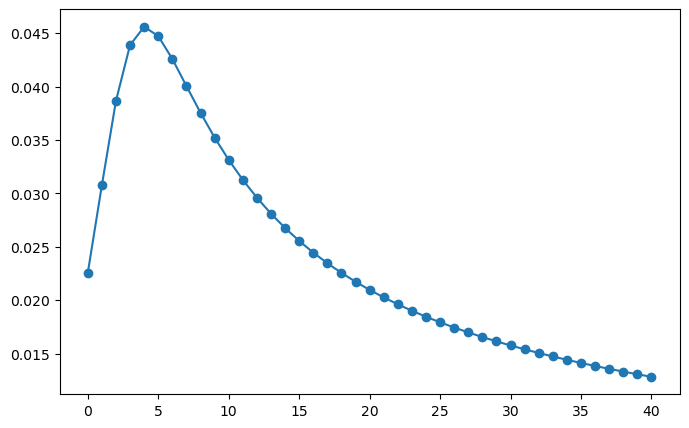

In [62]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fg_sfc['t'],fg_sfc['rsq'], marker='o', label='R-squared')

In [11]:
import numpy as np
a = np.load('D:\Shanghaitec\PROJECT\CSVD\preview\sub-074_wb_mi-wei_schaefer-400.npy')
a[1,5,15]

0.17547688338574674